# **Notebook 2: Data Preparation**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `sampled_data.csv` — Created by Notebook 1
- [ ] `corporate_policies/` folder with `.md` SOP files
- [ ] Internet access (to download the tokenizer)

**Files this notebook will CREATE:**
- [ ] `./tokenized_train/`, `./tokenized_valid/`, `./tokenized_test/` — HuggingFace datasets _(Required by NB6)_
- [ ] `df_test.csv` — Test set with readable text + labels _(Required by NB5 and NB7)_

---

In [2]:
# ============================================================
# COLAB PROJECT SETUP
# ============================================================

from google.colab import drive
from pathlib import Path
import os

# Mount Google Drive
drive.mount("/content/drive")

# Permanent project folder in Google Drive
DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Hybrid_RAG_Customer_Support"
)

# Temporary workspace for the current Colab runtime
LOCAL_PROJECT_DIR = Path(
    "/content/Hybrid_RAG_Customer_Support"
)

LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Work from the temporary Colab directory
os.chdir(LOCAL_PROJECT_DIR)

print("Google Drive project:", DRIVE_PROJECT_DIR)
print("Local Colab workspace:", LOCAL_PROJECT_DIR)
print("Current working directory:", Path.cwd())

Mounted at /content/drive
Google Drive project: /content/drive/MyDrive/Hybrid_RAG_Customer_Support
Local Colab workspace: /content/Hybrid_RAG_Customer_Support
Current working directory: /content/Hybrid_RAG_Customer_Support


## **Stage 2: Data Preparation**
### **Task 2.1: Clean and Validate Dataset**

#### **2.1.1 Remove Duplicate and Invalid Records [2 marks]**
**The Task:** Identify and remove duplicate records using normalised deduplication (lowercase + strip before comparison), plus any invalid, incomplete, or corrupted records.

**Hints & Tips:**
* Load `sampled_data.csv` from Notebook 1 first.
* Normalised dedup: create a temporary `_norm` column = `instruction.str.lower().str.strip()`, drop duplicates on it, then drop the helper column.
* Check for nulls in `instruction`, `intent`, and `category` — drop rows missing any of these targets.
* Print the number of rows removed so the cleaning is auditable.

**Why we are doing it:** To prevent degraded training from redundant or broken records, and to stop near-duplicates leaking across train/test splits later.
**How we are doing it:** Pandas normalised deduplication and null filtering.

**Learner Inference:** Exact-match dedup misses `"Where is my order?"` vs `"where is my order?"`. Normalising first catches these and keeps your splits clean.

In [3]:
# YOUR CODE HERE
import pandas as pd
from IPython.display import display

# Notebook 1 artefact
SAMPLED_DATA_PATH = (
    DRIVE_PROJECT_DIR
    / "artifacts"
    / "notebook_1"
    / "sampled_data.csv"
)

if not SAMPLED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"sampled_data.csv was not found at:\n{SAMPLED_DATA_PATH}"
    )

# Load the dataset
df_raw = pd.read_csv(SAMPLED_DATA_PATH)

REQUIRED_COLUMNS = ["instruction", "intent", "category"]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

print(f"Loaded dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

Loaded dataset shape: (4000, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


In [4]:
# Audit data quality before cleaning
null_rows = df_raw[REQUIRED_COLUMNS].isna().any(axis=1)

empty_rows = (
    df_raw[REQUIRED_COLUMNS]
    .fillna("")
    .apply(lambda column: column.astype(str).str.strip().eq(""))
    .any(axis=1)
)

normalised_instruction = (
    df_raw["instruction"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

duplicate_rows = normalised_instruction.duplicated(
    keep="first"
)

print("\nQuality audit before cleaning")
print("-" * 45)
print(f"Total records                : {len(df_raw):,}")
print(f"Rows with null values        : {null_rows.sum():,}")
print(f"Rows with empty fields       : {empty_rows.sum():,}")
print(f"Normalised duplicate prompts : {duplicate_rows.sum():,}")


Quality audit before cleaning
---------------------------------------------
Total records                : 4,000
Rows with null values        : 0
Rows with empty fields       : 0
Normalised duplicate prompts : 0


In [5]:
# Clean the dataset
df_cleaned = df_raw.copy()

# Remove incomplete records
df_cleaned = df_cleaned.dropna(
    subset=REQUIRED_COLUMNS
).copy()

# Standardise surrounding whitespace before validation
for column in REQUIRED_COLUMNS:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype(str)
        .str.strip()
    )

# Remove empty or whitespace-only records
valid_record_mask = (
    df_cleaned[REQUIRED_COLUMNS]
    .ne("")
    .all(axis=1)
)

df_cleaned = df_cleaned[
    valid_record_mask
].copy()

# Create temporary normalised prompt for deduplication
df_cleaned["_norm"] = (
    df_cleaned["instruction"]
    .str.lower()
    .str.strip()
)

# Remove normalised duplicate customer instructions
df_cleaned = (
    df_cleaned
    .drop_duplicates(
        subset="_norm",
        keep="first"
    )
    .drop(columns="_norm")
    .reset_index(drop=True)
)

In [6]:
# Final validation and audit
remaining_normalised_prompts = (
    df_cleaned["instruction"]
    .str.lower()
    .str.strip()
)

assert not df_cleaned[REQUIRED_COLUMNS].isna().any().any()

assert not (
    df_cleaned[REQUIRED_COLUMNS]
    .apply(lambda column: column.str.strip().eq(""))
    .any()
    .any()
)

assert not remaining_normalised_prompts.duplicated().any()

rows_removed = len(df_raw) - len(df_cleaned)

print("\nCleaning results")
print("-" * 45)
print(f"Rows before cleaning          : {len(df_raw):,}")
print(f"Rows removed                  : {rows_removed:,}")
print(f"Rows after cleaning           : {len(df_cleaned):,}")
print("Remaining null values         : 0")
print("Remaining empty fields        : 0")
print("Remaining duplicate prompts   : 0")

display(df_cleaned.head())


Cleaning results
---------------------------------------------
Rows before cleaning          : 4,000
Rows removed                  : 0
Rows after cleaning           : 4,000
Remaining null values         : 0
Remaining empty fields        : 0
Remaining duplicate prompts   : 0


,flags,instruction,category,intent,response
0,BLS,shipments to {{Delivery City}},DELIVERY,delivery_options,"Ah, {{Delivery City}}! A city renowned for its..."
1,BLMQZ,I'm trying to notify of errors with registrat...,ACCOUNT,registration_problems,Thank you for bringing this issue to our atten...
2,BCEMQ,i cannot pay help me to report issues with pay...,PAYMENT,payment_issue,I'm sorry to hear that you're having trouble w...
3,BCIL,"I have to see when will my product arrive, how...",DELIVERY,delivery_period,We understand your eagerness to know the estim...
4,BLQZ,need help to check in which cases can Irequest...,REFUND,check_refund_policy,I'm happy to help! I completely understand you...


#### **2.1.2 Standardise Dataset Formatting [2 marks]**
**The Task:** Clean the strings inside `instruction`, `intent`, and `category` by stripping whitespace and enforcing uniform casing (intents = lower, categories = upper).

**Hints & Tips:**
* Use Pandas `.str.strip()`, `.str.lower()`, `.str.upper()`.
* Always strip whitespace BEFORE lowering — trailing spaces survive `.lower()`.
* Standardised casing prevents the model treating "Refund" and "refund" as different classes.

**Why we are doing it:** To ensure raw strings are perfectly standardised before injecting them into prompt templates.
**How we are doing it:** Pandas string manipulation.

**Learner Inference:** Standardising capitalisation prevents the model from treating the same intent written two ways as two separate classes.

In [7]:
# YOUR CODE HERE
# Preserve the cleaned dataset from Task 2.1.1
df_standardized = df_cleaned.copy()

# Standardise text formatting
df_standardized["instruction"] = (
    df_standardized["instruction"]
    .astype(str)
    .str.strip()
)

df_standardized["intent"] = (
    df_standardized["intent"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_standardized["category"] = (
    df_standardized["category"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Retain the required schema in a consistent order
STANDARD_COLUMNS = [
    "instruction",
    "intent",
    "category"
]

df_standardized = (
    df_standardized[STANDARD_COLUMNS]
    .reset_index(drop=True)
)

In [8]:
# Validate formatting
assert not df_standardized.isna().any().any()

assert not (
    df_standardized
    .apply(lambda column: column.str.strip().eq(""))
    .any()
    .any()
)

assert (
    df_standardized["intent"]
    == df_standardized["intent"].str.lower()
).all()

assert (
    df_standardized["category"]
    == df_standardized["category"].str.upper()
).all()

assert df_standardized.columns.tolist() == STANDARD_COLUMNS

# Display standardisation results
print("Dataset formatting standardised successfully")
print("-" * 45)
print(f"Dataset shape      : {df_standardized.shape}")
print(f"Column order       : {df_standardized.columns.tolist()}")
print(f"Unique intents     : {df_standardized['intent'].nunique()}")
print(f"Unique categories  : {df_standardized['category'].nunique()}")

print("\nSample standardised records:")
display(df_standardized.head())

Dataset formatting standardised successfully
---------------------------------------------
Dataset shape      : (4000, 3)
Column order       : ['instruction', 'intent', 'category']
Unique intents     : 27
Unique categories  : 11

Sample standardised records:


,instruction,intent,category
0,shipments to {{Delivery City}},delivery_options,DELIVERY
1,I'm trying to notify of errors with registrat...,registration_problems,ACCOUNT
2,i cannot pay help me to report issues with pay...,payment_issue,PAYMENT
3,"I have to see when will my product arrive, how...",delivery_period,DELIVERY
4,need help to check in which cases can Irequest...,check_refund_policy,REFUND


### **Task 2.2: Create Instruction-Tuning Dataset**

#### **2.2.1 Transform Records into Instruction Format [2 marks]**
**The Task:** Wrap the raw instructions and targets into a standardized `ChatML` format, forcing the assistant's response to be a strict JSON string containing the `intent` and `category`.

**Hints & Tips:**
* Use the Qwen tokenizer's `apply_chat_template(tokenize=False)`.
* The target JSON is `{"intent": "...", "category": "..."}` — built via `json.dumps()`.

**Model Selection:**
* **Qwen/Qwen2.5-1.5B-Instruct** (recommended) — fits T4, strong instruction following.
* **TinyLlama-1.1B-Chat** — lighter but weaker at structured output.
* **Llama-3-8B-Instruct** — best quality, needs >16GB VRAM even in 4-bit.
* Whatever you pick, set `MODEL_ID` here and in ALL later notebooks.

**Learner Inference:** Formatting the target as JSON establishes the exact structural rules the LoRA model learns to mimic in Stage 4.

In [9]:
# YOUR CODE HERE
!pip install -q transformers

In [10]:
import json
import pandas as pd
from transformers import AutoTokenizer
from IPython.display import display

# Keep this model ID unchanged in all later notebooks
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

# Download and configure the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    use_fast=True
)

SYSTEM_PROMPT = (
    "You are a customer-support intent classification assistant. "
    "Return only a valid JSON object containing exactly two keys: "
    "'intent' and 'category'. Do not include explanations, Markdown, "
    "code fences, or any text outside the JSON object."
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [11]:
def create_instruction_record(row):
    """Convert one standardised record into ChatML format."""

    # Construct a strict JSON target
    target_json = json.dumps(
        {
            "intent": row["intent"],
            "category": row["category"]
        },
        ensure_ascii=False,
        separators=(",", ":")
    )

    # Create the ChatML message sequence
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": row["instruction"]
        },
        {
            "role": "assistant",
            "content": target_json
        }
    ]

    # Apply Qwen's official chat template
    chatml_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    return pd.Series({
        "messages": messages,
        "target_json": target_json,
        "chatml_text": chatml_text
    })


# Transform all standardised records
instruction_columns = df_standardized.apply(
    create_instruction_record,
    axis=1
)

df_instruction = pd.concat(
    [
        df_standardized.reset_index(drop=True),
        instruction_columns.reset_index(drop=True)
    ],
    axis=1
)

# Display transformation results
print("Instruction-tuning dataset created successfully")
print("-" * 50)
print(f"Model ID          : {MODEL_ID}")
print(f"Number of records : {len(df_instruction):,}")
print(f"Columns           : {df_instruction.columns.tolist()}")

print("\nExample strict JSON target:")
print(df_instruction.loc[0, "target_json"])

print("\nExample ChatML-formatted record:")
print(df_instruction.loc[0, "chatml_text"])

display(
    df_instruction[
        [
            "instruction",
            "intent",
            "category",
            "target_json"
        ]
    ].head()
)

Instruction-tuning dataset created successfully
--------------------------------------------------
Model ID          : Qwen/Qwen2.5-1.5B-Instruct
Number of records : 4,000
Columns           : ['instruction', 'intent', 'category', 'messages', 'target_json', 'chatml_text']

Example strict JSON target:
{"intent":"delivery_options","category":"DELIVERY"}

Example ChatML-formatted record:
<|im_start|>system
You are a customer-support intent classification assistant. Return only a valid JSON object containing exactly two keys: 'intent' and 'category'. Do not include explanations, Markdown, code fences, or any text outside the JSON object.<|im_end|>
<|im_start|>user
shipments to {{Delivery City}}<|im_end|>
<|im_start|>assistant
{"intent":"delivery_options","category":"DELIVERY"}<|im_end|>



,instruction,intent,category,target_json
0,shipments to {{Delivery City}},delivery_options,DELIVERY,"{""intent"":""delivery_options"",""category"":""DELIV..."
1,I'm trying to notify of errors with registrat...,registration_problems,ACCOUNT,"{""intent"":""registration_problems"",""category"":""..."
2,i cannot pay help me to report issues with pay...,payment_issue,PAYMENT,"{""intent"":""payment_issue"",""category"":""PAYMENT""}"
3,"I have to see when will my product arrive, how...",delivery_period,DELIVERY,"{""intent"":""delivery_period"",""category"":""DELIVE..."
4,need help to check in which cases can Irequest...,check_refund_policy,REFUND,"{""intent"":""check_refund_policy"",""category"":""RE..."


#### **2.2.2 Validate Instruction Templates [2 marks]**
**The Task:** Extract the assistant's portion of the generated ChatML string and parse it with `json.loads()` to verify structural integrity.

**Hints & Tips:**
* Split the string by `<|im_start|>assistant` and parse what follows.
* If this throws `JSONDecodeError`, your formatting in 2.2.1 is broken — fix before training.
* Validate several samples, not just the first.

**Learner Inference:** A JSONDecodeError here means the model would learn broken syntax. Catching it now saves a failed training run.

In [12]:
# YOUR CODE HERE
ASSISTANT_START = "<|im_start|>assistant\n"
MESSAGE_END = "<|im_end|>"
EXPECTED_KEYS = {"intent", "category"}


def validate_chatml_record(row):
    """
    Extract and validate the assistant JSON from one ChatML record.
    """

    chatml_text = row["chatml_text"]

    try:
        # Confirm that the assistant section exists
        if ASSISTANT_START not in chatml_text:
            raise ValueError(
                "Assistant section is missing from the ChatML template."
            )

        # Extract only the assistant response
        assistant_section = (
            chatml_text
            .split(ASSISTANT_START, maxsplit=1)[1]
            .split(MESSAGE_END, maxsplit=1)[0]
            .strip()
        )

        # Parse the assistant response as JSON
        parsed_target = json.loads(assistant_section)

        # Validate JSON object type
        if not isinstance(parsed_target, dict):
            raise ValueError(
                "Assistant target is not a JSON object."
            )

        # Validate exact schema
        if set(parsed_target.keys()) != EXPECTED_KEYS:
            raise ValueError(
                f"Invalid keys: {set(parsed_target.keys())}"
            )

        # Validate target values against the source columns
        if parsed_target["intent"] != row["intent"]:
            raise ValueError(
                "Parsed intent does not match the source intent."
            )

        if parsed_target["category"] != row["category"]:
            raise ValueError(
                "Parsed category does not match the source category."
            )

        # Validate casing rules
        if parsed_target["intent"] != parsed_target["intent"].lower():
            raise ValueError(
                "Intent is not lowercase."
            )

        if parsed_target["category"] != parsed_target["category"].upper():
            raise ValueError(
                "Category is not uppercase."
            )

        return pd.Series({
            "template_valid": True,
            "validation_error": None,
            "parsed_intent": parsed_target["intent"],
            "parsed_category": parsed_target["category"],
            "assistant_json": assistant_section
        })

    except (json.JSONDecodeError, ValueError, IndexError) as error:
        return pd.Series({
            "template_valid": False,
            "validation_error": str(error),
            "parsed_intent": None,
            "parsed_category": None,
            "assistant_json": None
        })


# Validate every instruction-tuning record
validation_results = df_instruction.apply(
    validate_chatml_record,
    axis=1
)

df_instruction_validated = pd.concat(
    [
        df_instruction.reset_index(drop=True),
        validation_results.reset_index(drop=True)
    ],
    axis=1
)

In [13]:
# Validation summary
valid_count = int(
    df_instruction_validated["template_valid"].sum()
)

invalid_count = int(
    (~df_instruction_validated["template_valid"]).sum()
)

validation_rate = (
    valid_count / len(df_instruction_validated) * 100
)

print("Instruction-template validation results")
print("-" * 50)
print(f"Total records       : {len(df_instruction_validated):,}")
print(f"Valid templates     : {valid_count:,}")
print(f"Invalid templates   : {invalid_count:,}")
print(f"Template validity   : {validation_rate:.2f}%")

Instruction-template validation results
--------------------------------------------------
Total records       : 4,000
Valid templates     : 4,000
Invalid templates   : 0
Template validity   : 100.00%


In [14]:
# Display invalid records if any exist
if invalid_count > 0:
    print("\nInvalid records:")
    display(
        df_instruction_validated.loc[
            ~df_instruction_validated["template_valid"],
            [
                "instruction",
                "target_json",
                "validation_error"
            ]
        ]
    )
else:
    print(
        "\nAll ChatML templates contain valid, "
        "schema-compliant JSON targets."
    )


# Display several validated samples
print("\nValidated sample targets:")

display(
    df_instruction_validated[
        [
            "instruction",
            "assistant_json",
            "parsed_intent",
            "parsed_category",
            "template_valid"
        ]
    ].sample(
        n=min(5, len(df_instruction_validated)),
        random_state=42
    )
)


# Stop execution if any template is invalid
assert invalid_count == 0, (
    f"{invalid_count} invalid instruction template(s) detected."
)


All ChatML templates contain valid, schema-compliant JSON targets.

Validated sample targets:


,instruction,assistant_json,parsed_intent,parsed_category,template_valid
555,I can't check if there is anything wrong with ...,"{""intent"":""track_refund"",""category"":""REFUND""}",track_refund,REFUND,True
3491,want help seeing the withdrawal charge,"{""intent"":""check_cancellation_fee"",""category"":...",check_cancellation_fee,CANCEL,True
527,what do I have to do to retrieve my key?,"{""intent"":""recover_password"",""category"":""ACCOU...",recover_password,ACCOUNT,True
3925,can you help me to see the damn ETA of order {...,"{""intent"":""track_order"",""category"":""ORDER""}",track_order,ORDER,True
2989,I cannot check the status of my newsletter sub...,"{""intent"":""newsletter_subscription"",""category""...",newsletter_subscription,SUBSCRIPTION,True


### **Task 2.3: Engineer Training and Retrieval Data**

#### **2.3.1 Tokenise Dataset [2 marks]**
**The Task:** Convert text sequences into tensor IDs and apply `-100` masking to padding tokens in the `labels` array.

**Hints & Tips:**
* If a token equals `tokenizer.pad_token_id`, replace it with `-100` in labels.
* `-100` is PyTorch's ignore index — the loss skips these tokens.

**Parameter Tuning:**
* `max_length`: `128` (fast, fits most Bitext prompts), `256` (safer if truncation seen), `64` (too aggressive).

**Learner Inference:** Masking isolates the loss — the model is penalised for wrong JSON, not for padding.

In [15]:
# YOUR CODE HERE
from datasets import Dataset
import numpy as np

MAX_LENGTH = 128

# Ensure the tokenizer has a padding token
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# Use only records that passed template validation
tokenisation_df = (
    df_instruction_validated.loc[
        df_instruction_validated["template_valid"],
        [
            "instruction",
            "intent",
            "category",
            "chatml_text"
        ]
    ]
    .reset_index(drop=True)
)

# Convert the Pandas DataFrame into a Hugging Face Dataset
instruction_dataset = Dataset.from_pandas(
    tokenisation_df,
    preserve_index=False
)


def tokenise_batch(batch):
    """
    Convert ChatML strings into model-ready token sequences and
    mask padding positions in labels using -100.
    """

    encoded = tokenizer(
        batch["chatml_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,

        # ChatML control tokens were already added by
        # apply_chat_template() in Task 2.2.1
        add_special_tokens=False
    )

    labels = []

    for input_ids, attention_mask in zip(
        encoded["input_ids"],
        encoded["attention_mask"]
    ):
        # Copy input IDs as causal-language-modelling labels.
        # Ignore only padded positions during loss calculation.
        record_labels = [
            token_id if mask_value == 1 else -100
            for token_id, mask_value in zip(
                input_ids,
                attention_mask
            )
        ]

        labels.append(record_labels)

    encoded["labels"] = labels

    return encoded


# Tokenise the complete validated instruction dataset
tokenized_dataset = instruction_dataset.map(
    tokenise_batch,
    batched=True,
    desc="Tokenising ChatML records"
)

Tokenising ChatML records:   0%|          | 0/4000 [00:00<?, ? examples/s]

In [16]:
# Validate tokenisation
assert len(tokenized_dataset) == len(df_instruction_validated)

assert all(
    len(record["input_ids"]) == MAX_LENGTH
    for record in tokenized_dataset
)

assert all(
    len(record["attention_mask"]) == MAX_LENGTH
    for record in tokenized_dataset
)

assert all(
    len(record["labels"]) == MAX_LENGTH
    for record in tokenized_dataset
)

# Verify that padding positions are masked with -100
for record in tokenized_dataset:
    for token_id, mask_value, label in zip(
        record["input_ids"],
        record["attention_mask"],
        record["labels"]
    ):
        if mask_value == 0:
            assert label == -100
        else:
            assert label == token_id

In [17]:
# Tokenisation summary
total_tokens = (
    len(tokenized_dataset) * MAX_LENGTH
)

active_tokens = sum(
    sum(record["attention_mask"])
    for record in tokenized_dataset
)

masked_tokens = sum(
    label == -100
    for record in tokenized_dataset
    for label in record["labels"]
)

print("Tokenisation completed successfully")
print("-" * 50)
print(f"Model ID             : {MODEL_ID}")
print(f"Number of records    : {len(tokenized_dataset):,}")
print(f"Maximum sequence size: {MAX_LENGTH}")
print(f"Padding token        : {tokenizer.pad_token}")
print(f"Padding token ID     : {tokenizer.pad_token_id}")
print(f"Total token positions: {total_tokens:,}")
print(f"Active tokens        : {active_tokens:,}")
print(f"Masked padding tokens: {masked_tokens:,}")

# Display one tokenised example
sample = tokenized_dataset[0]

print("\nFirst tokenised record")
print("-" * 50)
print("Input IDs:")
print(sample["input_ids"])

print("\nAttention mask:")
print(sample["attention_mask"])

print("\nLabels:")
print(sample["labels"])

print("\nDecoded active sequence:")
print(
    tokenizer.decode(
        [
            token_id
            for token_id, mask_value in zip(
                sample["input_ids"],
                sample["attention_mask"]
            )
            if mask_value == 1
        ],
        skip_special_tokens=False
    )
)

Tokenisation completed successfully
--------------------------------------------------
Model ID             : Qwen/Qwen2.5-1.5B-Instruct
Number of records    : 4,000
Maximum sequence size: 128
Padding token        : <|endoftext|>
Padding token ID     : 151643
Total token positions: 512,000
Active tokens        : 325,050
Masked padding tokens: 186,950

First tokenised record
--------------------------------------------------
Input IDs:
[151644, 8948, 198, 2610, 525, 264, 6002, 55947, 7385, 23850, 17847, 13, 3411, 1172, 264, 2697, 4718, 1633, 8482, 6896, 1378, 6894, 25, 364, 56431, 6, 323, 364, 5471, 4427, 3155, 537, 2924, 40841, 11, 73192, 11, 2038, 69155, 11, 476, 894, 1467, 4889, 279, 4718, 1633, 13, 151645, 198, 151644, 872, 198, 5270, 1368, 311, 5867, 38121, 4311, 3417, 151645, 198, 151644, 77091, 198, 4913, 56431, 3252, 32390, 8743, 2198, 5471, 3252, 38332, 64824, 9207, 151645, 198, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 1516

#### **2.3.2 Analyse Token Distributions [2 marks]**
**The Task:** Analyse the token-count distribution to detect truncation risks and verify the sequence-length configuration.

**Hints & Tips:**
* Count non-padding tokens per row and plot a histogram.
* If >5% of rows hit `max_length`, increase it.
* The JSON target is ~20 tokens — if truncated, the model learns incomplete output.

**Learner Inference:** Sequences hitting the ceiling mean the JSON target is getting cut off, teaching the model to produce broken output.

In [19]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

# Count non-padding tokens in the tokenised dataset
active_token_counts = np.array([
    sum(record["attention_mask"])
    for record in tokenized_dataset
])

# Calculate original lengths without padding or truncation
raw_token_counts = np.array([
    len(
        tokenizer(
            text,
            add_special_tokens=False,
            truncation=False
        )["input_ids"]
    )
    for text in tokenisation_df["chatml_text"]
])


# Create a reusable summary DataFrame
token_length_df = pd.DataFrame({
    "active_tokens_after_processing": active_token_counts,
    "original_token_count": raw_token_counts
})

token_length_df["would_be_truncated"] = (
    token_length_df["original_token_count"] > MAX_LENGTH
)

token_length_df["hits_length_ceiling"] = (
    token_length_df["active_tokens_after_processing"] == MAX_LENGTH
)

# 3. Calculate sequence-length statistics
truncated_count = int(
    token_length_df["would_be_truncated"].sum()
)

ceiling_count = int(
    token_length_df["hits_length_ceiling"].sum()
)

truncation_rate = (
    truncated_count / len(token_length_df) * 100
)

ceiling_rate = (
    ceiling_count / len(token_length_df) * 100
)

length_summary = token_length_df[
    "original_token_count"
].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("token_count")

print("Token-length analysis")
print("-" * 50)
print(f"Number of records             : {len(token_length_df):,}")
print(f"Configured maximum length     : {MAX_LENGTH}")
print(f"Minimum original length       : {raw_token_counts.min()}")
print(f"Mean original length          : {raw_token_counts.mean():.2f}")
print(f"Median original length        : {np.median(raw_token_counts):.2f}")
print(f"Maximum original length       : {raw_token_counts.max()}")
print(f"Records hitting the ceiling   : {ceiling_count:,}")
print(f"Ceiling rate                  : {ceiling_rate:.2f}%")
print(f"Records exceeding MAX_LENGTH  : {truncated_count:,}")
print(f"Estimated truncation rate     : {truncation_rate:.2f}%")

print("\nDetailed token-count statistics:")
display(length_summary.round(2))

Token-length analysis
--------------------------------------------------
Number of records             : 4,000
Configured maximum length     : 128
Minimum original length       : 71
Mean original length          : 81.26
Median original length        : 81.00
Maximum original length       : 93
Records hitting the ceiling   : 0
Ceiling rate                  : 0.00%
Records exceeding MAX_LENGTH  : 0
Estimated truncation rate     : 0.00%

Detailed token-count statistics:


,token_count
count,4000.00
mean,81.26
std,3.18
min,71.00
50%,81.00
75%,83.00
90%,85.00
95%,87.00
99%,90.00
max,93.00


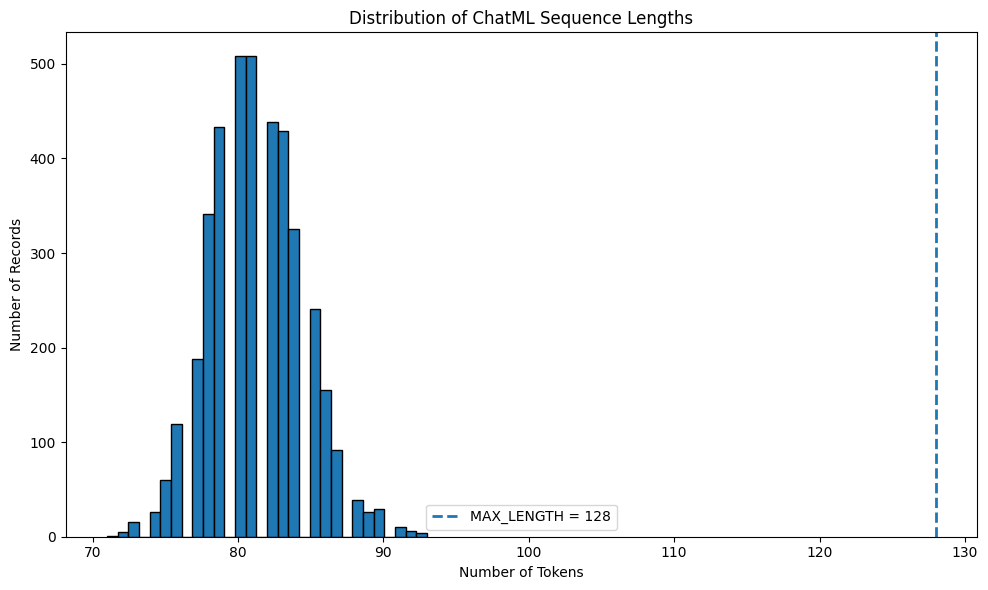

In [20]:
# Plot the original token-count distribution
plt.figure(figsize=(10, 6))

plt.hist(
    raw_token_counts,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    MAX_LENGTH,
    linestyle="--",
    linewidth=2,
    label=f"MAX_LENGTH = {MAX_LENGTH}"
)

plt.title("Distribution of ChatML Sequence Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Records")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Assess truncation risk
print("Sequence-length recommendation")
print("-" * 50)

if truncation_rate > 5:
    print(
        f"Truncation risk is high: {truncation_rate:.2f}% of "
        f"records exceed MAX_LENGTH={MAX_LENGTH}."
    )
    print(
        "Increase MAX_LENGTH to 256 and rerun Task 2.3.1 "
        "before creating the dataset partitions."
    )

elif truncated_count > 0:
    print(
        f"Truncation is limited to {truncation_rate:.2f}% of records."
    )
    print(
        "Inspect the affected records to confirm that the assistant "
        "JSON target is not being truncated."
    )

else:
    print(
        f"No records exceed MAX_LENGTH={MAX_LENGTH}. "
        "The selected sequence length is sufficient."
    )


# Display the longest records for inspection
print("\nFive longest sequences:")

longest_indices = (
    token_length_df["original_token_count"]
    .nlargest(5)
    .index
)

display(
    pd.concat(
        [
            tokenisation_df.loc[
                longest_indices,
                ["instruction", "intent", "category"]
            ],
            token_length_df.loc[
                longest_indices,
                ["original_token_count", "would_be_truncated"]
            ]
        ],
        axis=1
    ).sort_values(
        "original_token_count",
        ascending=False
    )
)

Sequence-length recommendation
--------------------------------------------------
No records exceed MAX_LENGTH=128. The selected sequence length is sufficient.

Five longest sequences:


,instruction,intent,category,original_token_count,would_be_truncated
2117,I paid {{Currency Symbol}}{{Refund Amount}} fo...,get_refund,REFUND,93,False
2631,I have paid {{Currency Symbol}}{{Refund Amount...,get_refund,REFUND,93,False
3007,I paid {{Currency Symbol}}{{Refund Amount}} fo...,get_refund,REFUND,93,False
3076,i have paid {{Currency Symbol}}{{Refund Amount...,get_refund,REFUND,93,False
624,I paid {{Currency Symbol}}{{Refund Amount}} fo...,get_refund,REFUND,92,False


#### **2.3.3 Prepare Retrieval Corpus [3 marks]**
**The Task:** Ingest the Markdown SOPs into LangChain Document objects ready to be embedded.

**Hints & Tips:**
* Use `TextLoader` from LangChain.
* Each `.md` file becomes one `Document` with `.page_content` and `.metadata`.
* These documents are embedded into ChromaDB in Notebook 4.

**Learner Inference:** These document objects form the knowledge base your bot retrieves from in Stages 3 and 4.

In [22]:
# YOUR CODE HERE
!pip install -q langchain-community langchain-text-splitters

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


/tmp/ipykernel_325/331441597.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [24]:
# Locate the corporate SOP files
POLICY_DIR = (
    DRIVE_PROJECT_DIR
    / "data"
    / "corporate_policies"
)

if not POLICY_DIR.exists():
    raise FileNotFoundError(
        f"Corporate policy directory was not found:\n{POLICY_DIR}"
    )

policy_files = sorted(POLICY_DIR.glob("*.md"))

if not policy_files:
    raise FileNotFoundError(
        f"No Markdown SOP files were found in:\n{POLICY_DIR}"
    )

print(f"Policy directory : {POLICY_DIR}")
print(f"SOP files found  : {len(policy_files)}")

Policy directory : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/data/corporate_policies
SOP files found  : 13


In [25]:
# Load each Markdown file as a LangChain Document
sop_documents = []

for file_path in policy_files:

    loader = TextLoader(
        str(file_path),
        encoding="utf-8"
    )

    loaded_documents = loader.load()

    for document in loaded_documents:
        document.metadata.update({
            "source_file": file_path.name,
            "document_name": file_path.stem
        })

        sop_documents.append(document)


# Validate the loaded documents
assert len(sop_documents) == len(policy_files)

assert all(
    document.page_content.strip()
    for document in sop_documents
)

assert all(
    "source_file" in document.metadata
    for document in sop_documents
)

print(f"LangChain documents loaded: {len(sop_documents)}")

LangChain documents loaded: 13


In [26]:
# Split SOP documents into retrieval-ready chunks
CHUNK_SIZE = 500
CHUNK_OVERLAP = 75

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=[
        "\n## ",
        "\n### ",
        "\n\n",
        "\n",
        " ",
        ""
    ],
    length_function=len
)

retrieval_chunks = text_splitter.split_documents(
    sop_documents
)


# Add a stable chunk identifier to each chunk
source_chunk_counts = {}

for chunk in retrieval_chunks:

    source_file = chunk.metadata["source_file"]

    chunk_number = source_chunk_counts.get(
        source_file,
        0
    )

    chunk.metadata["chunk_id"] = (
        f"{Path(source_file).stem}_chunk_{chunk_number:03d}"
    )

    source_chunk_counts[source_file] = (
        chunk_number + 1
    )

In [27]:
# Validate retrieval-corpus quality
assert retrieval_chunks, (
    "No retrieval chunks were created."
)

assert all(
    chunk.page_content.strip()
    for chunk in retrieval_chunks
)

assert all(
    "source_file" in chunk.metadata
    and "document_name" in chunk.metadata
    and "chunk_id" in chunk.metadata
    for chunk in retrieval_chunks
)

chunk_summary = pd.DataFrame([
    {
        "chunk_id": chunk.metadata["chunk_id"],
        "source_file": chunk.metadata["source_file"],
        "character_count": len(chunk.page_content),
        "word_count": len(chunk.page_content.split()),
        "is_non_empty": bool(chunk.page_content.strip())
    }
    for chunk in retrieval_chunks
])

duplicate_chunk_count = (
    chunk_summary
    .assign(
        normalized_text=[
            " ".join(
                chunk.page_content
                .lower()
                .split()
            )
            for chunk in retrieval_chunks
        ]
    )["normalized_text"]
    .duplicated()
    .sum()
)

print("\nRetrieval-corpus summary")
print("-" * 50)
print(f"Original SOP documents : {len(sop_documents)}")
print(f"Retrieval chunks       : {len(retrieval_chunks)}")
print(f"Chunk size             : {CHUNK_SIZE} characters")
print(f"Chunk overlap          : {CHUNK_OVERLAP} characters")
print(f"Empty chunks           : {(~chunk_summary['is_non_empty']).sum()}")
print(f"Duplicate chunks       : {duplicate_chunk_count}")
print(
    f"Minimum chunk length   : "
    f"{chunk_summary['character_count'].min()}"
)
print(
    f"Maximum chunk length   : "
    f"{chunk_summary['character_count'].max()}"
)
print(
    f"Average chunk length   : "
    f"{chunk_summary['character_count'].mean():.2f}"
)


# Number of chunks generated per SOP
chunks_per_document = (
    chunk_summary
    .groupby("source_file")
    .size()
    .reset_index(name="chunk_count")
    .sort_values("source_file")
)

print("\nChunks per SOP document:")
display(chunks_per_document)

print("\nSample retrieval-ready chunks:")
display(chunk_summary.head())


# Display the content and metadata of one sample chunk
sample_chunk = retrieval_chunks[0]

print("\nSample chunk metadata:")
print(sample_chunk.metadata)

print("\nSample chunk content:")
print(sample_chunk.page_content)


Retrieval-corpus summary
--------------------------------------------------
Original SOP documents : 13
Retrieval chunks       : 65
Chunk size             : 500 characters
Chunk overlap          : 75 characters
Empty chunks           : 0
Duplicate chunks       : 0
Minimum chunk length   : 167
Maximum chunk length   : 494
Average chunk length   : 320.35

Chunks per SOP document:


,source_file,chunk_count
0,account_recovery.md,5
1,billing_disputes.md,5
2,data_privacy.md,5
3,escalation_matrix.md,5
4,order_tracking.md,5
5,password_reset.md,5
6,payment_methods.md,5
7,product_return.md,5
8,refund_policy.md,6
9,shipping_delays.md,5



Sample retrieval-ready chunks:


,chunk_id,source_file,character_count,word_count,is_non_empty
0,account_recovery_chunk_000,account_recovery.md,286,47,True
1,account_recovery_chunk_001,account_recovery.md,291,48,True
2,account_recovery_chunk_002,account_recovery.md,292,43,True
3,account_recovery_chunk_003,account_recovery.md,239,38,True
4,account_recovery_chunk_004,account_recovery.md,436,64,True



Sample chunk metadata:
{'source': '/content/drive/MyDrive/Hybrid_RAG_Customer_Support/data/corporate_policies/account_recovery.md', 'source_file': 'account_recovery.md', 'document_name': 'account_recovery', 'chunk_id': 'account_recovery_chunk_000'}

Sample chunk content:
# Account Recovery

## When To Use
Use this procedure when a customer cannot access their account due to a
lockout, a lost email address, suspected unauthorized access, or a disabled
account — anything beyond a simple forgotten password (see the password reset
procedure for that case).


### **Task 2.4: Create Dataset Partitions**

#### **2.4.1 Create Train, Validation, and Test Splits [5 marks]**
**The Task:** Split the tokenized dataset into Train (80%), Validation (10%), and Test (10%) partitions using stratified sampling. Demonstrate zero data leakage across all three.

**Hints & Tips:**
* Use `train_test_split` from sklearn with `stratify=df['intent']` so every intent appears in all splits.
* Split twice: first 80/20, then split the 20% into 50/50 (giving 10%/10%).
* The validation set is not optional — it is actively used during fine-tuning (Stage 4 / Notebook 6) for loss monitoring and early stopping.
* The test set must stay completely independent — used only for final evaluation.
* Verify zero overlap with set-intersection checks: `assert len(train_set & test_set) == 0`.
* Build a `df_test` DataFrame preserving readable `text`/`intent`/`category` columns for later scoring.

**Parameter Tuning:**
* Split ratio: `80/10/10` (recommended) or `70/15/15`. Any alternative must be justified.

**Why we are doing it:** To guarantee isolated, unseen data for unbiased evaluation, and a validation set for overfitting detection.
**How we are doing it:** Stratified sklearn splits with explicit programmatic leakage verification.

**Learner Inference:** Testing on data the model trained on gives false confidence (leakage). The held-out test split proves your model handles completely new phrasing; the validation split tells you when to stop training.

In [28]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split
from pathlib import Path
import shutil

RANDOM_STATE = 42

# tokenisation_df and tokenized_dataset must have identical order
assert len(tokenisation_df) == len(tokenized_dataset)

all_indices = np.arange(len(tokenisation_df))

# First split: 80% train and 20% temporary
train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=tokenisation_df["intent"]
)

# Second split: divide temporary set into 10% valid / 10% test
valid_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=tokenisation_df.loc[temp_indices, "intent"]
)

In [29]:
# Create readable DataFrame partitions
df_train = (
    tokenisation_df
    .iloc[train_indices]
    .reset_index(drop=True)
)

df_valid = (
    tokenisation_df
    .iloc[valid_indices]
    .reset_index(drop=True)
)

df_test = (
    tokenisation_df
    .iloc[test_indices]
    .reset_index(drop=True)
)

# Create tokenised Hugging Face Dataset partitions
tokenized_train = tokenized_dataset.select(
    train_indices.tolist()
)

tokenized_valid = tokenized_dataset.select(
    valid_indices.tolist()
)

tokenized_test = tokenized_dataset.select(
    test_indices.tolist()
)

# Verify split sizes
assert len(df_train) + len(df_valid) + len(df_test) == len(
    tokenisation_df
)

assert len(tokenized_train) == len(df_train)
assert len(tokenized_valid) == len(df_valid)
assert len(tokenized_test) == len(df_test)

print("Dataset partition sizes")
print("-" * 45)
print(
    f"Training   : {len(df_train):,} "
    f"({len(df_train) / len(tokenisation_df) * 100:.1f}%)"
)
print(
    f"Validation : {len(df_valid):,} "
    f"({len(df_valid) / len(tokenisation_df) * 100:.1f}%)"
)
print(
    f"Testing    : {len(df_test):,} "
    f"({len(df_test) / len(tokenisation_df) * 100:.1f}%)"
)

Dataset partition sizes
---------------------------------------------
Training   : 3,200 (80.0%)
Validation : 400 (10.0%)
Testing    : 400 (10.0%)


In [30]:
# Verify that every intent appears in every partition
all_intents = set(tokenisation_df["intent"])
train_intents = set(df_train["intent"])
valid_intents = set(df_valid["intent"])
test_intents = set(df_test["intent"])

assert train_intents == all_intents
assert valid_intents == all_intents
assert test_intents == all_intents

print("\nIntent coverage")
print("-" * 45)
print(f"Total intents       : {len(all_intents)}")
print(f"Training intents    : {len(train_intents)}")
print(f"Validation intents  : {len(valid_intents)}")
print(f"Testing intents     : {len(test_intents)}")
print("Every intent appears in all three partitions.")


Intent coverage
---------------------------------------------
Total intents       : 27
Training intents    : 27
Validation intents  : 27
Testing intents     : 27
Every intent appears in all three partitions.


In [31]:
# Verify zero prompt overlap and data leakage
def normalised_prompt_set(df):
    return set(
        df["instruction"]
        .astype(str)
        .str.lower()
        .str.strip()
    )


train_prompts = normalised_prompt_set(df_train)
valid_prompts = normalised_prompt_set(df_valid)
test_prompts = normalised_prompt_set(df_test)

train_valid_overlap = train_prompts.intersection(valid_prompts)
train_test_overlap = train_prompts.intersection(test_prompts)
valid_test_overlap = valid_prompts.intersection(test_prompts)

assert len(train_valid_overlap) == 0
assert len(train_test_overlap) == 0
assert len(valid_test_overlap) == 0

# Verify that the three sets collectively contain all records
combined_prompts = (
    train_prompts
    | valid_prompts
    | test_prompts
)

assert len(combined_prompts) == len(tokenisation_df)

print("\nData-leakage verification")
print("-" * 45)
print(
    f"Train–validation overlap : "
    f"{len(train_valid_overlap)}"
)
print(
    f"Train–test overlap       : "
    f"{len(train_test_overlap)}"
)
print(
    f"Validation–test overlap  : "
    f"{len(valid_test_overlap)}"
)
print("No duplicate prompts occur across partitions.")


Data-leakage verification
---------------------------------------------
Train–validation overlap : 0
Train–test overlap       : 0
Validation–test overlap  : 0
No duplicate prompts occur across partitions.


In [32]:
# Display class distribution across partitions
split_distribution = pd.concat(
    [
        df_train["intent"]
        .value_counts()
        .rename("train"),
        df_valid["intent"]
        .value_counts()
        .rename("validation"),
        df_test["intent"]
        .value_counts()
        .rename("test")
    ],
    axis=1
).fillna(0).astype(int)

split_distribution["total"] = (
    split_distribution["train"]
    + split_distribution["validation"]
    + split_distribution["test"]
)

split_distribution = split_distribution.sort_values(
    "total",
    ascending=False
)

print("\nIntent distribution across partitions:")
display(split_distribution)

# Prepare readable held-out test artefact
df_test_export = df_test[
    [
        "instruction",
        "intent",
        "category"
    ]
].copy()

assert len(df_test_export) == len(tokenized_test)


Intent distribution across partitions:


,train,validation,test,total
intent,,,,
get_invoice,137,17,17,171
review,137,17,17,171
create_account,132,16,17,165
check_payment_methods,131,17,16,164
set_up_shipping_address,130,16,16,162
payment_issue,129,16,16,161
contact_customer_service,129,16,16,161
change_shipping_address,127,16,16,159
contact_human_agent,127,16,16,159


---
## Save Artifacts for Downstream Notebooks

**IMPORTANT:** These cells save all datasets. Notebooks 5, 6, and 7 depend on them.

In [33]:
# YOUR CODE HERE
NOTEBOOK_2_ARTIFACT_DIR = (
    DRIVE_PROJECT_DIR
    / "artifacts"
    / "notebook_2"
)

TOKENIZED_TRAIN_PATH = (
    NOTEBOOK_2_ARTIFACT_DIR
    / "tokenized_train"
)

TOKENIZED_VALID_PATH = (
    NOTEBOOK_2_ARTIFACT_DIR
    / "tokenized_valid"
)

TOKENIZED_TEST_PATH = (
    NOTEBOOK_2_ARTIFACT_DIR
    / "tokenized_test"
)

DF_TEST_PATH = (
    NOTEBOOK_2_ARTIFACT_DIR
    / "df_test.csv"
)

NOTEBOOK_2_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Remove existing folders so the cell can be rerun cleanly
for path in [
    TOKENIZED_TRAIN_PATH,
    TOKENIZED_VALID_PATH,
    TOKENIZED_TEST_PATH
]:
    if path.exists():
        shutil.rmtree(path)

# Save tokenised Hugging Face datasets
tokenized_train.save_to_disk(
    str(TOKENIZED_TRAIN_PATH)
)

tokenized_valid.save_to_disk(
    str(TOKENIZED_VALID_PATH)
)

tokenized_test.save_to_disk(
    str(TOKENIZED_TEST_PATH)
)

# Save readable held-out test data
df_test_export.to_csv(
    DF_TEST_PATH,
    index=False
)

print("Saved downstream artefacts")
print("-" * 45)
print(f"Training dataset   : {TOKENIZED_TRAIN_PATH}")
print(f"Validation dataset : {TOKENIZED_VALID_PATH}")
print(f"Test dataset       : {TOKENIZED_TEST_PATH}")
print(f"Readable test CSV  : {DF_TEST_PATH}")

print("\nReadable held-out test sample:")
display(df_test_export.head())

Saving the dataset (0/1 shards):   0%|          | 0/3200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/400 [00:00<?, ? examples/s]

Saved downstream artefacts
---------------------------------------------
Training dataset   : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_2/tokenized_train
Validation dataset : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_2/tokenized_valid
Test dataset       : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_2/tokenized_test
Readable test CSV  : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_2/df_test.csv

Readable held-out test sample:


,instruction,intent,category
0,i have to call customer support can uhelp me,contact_customer_service,CONTACT
1,I want assistance informing of a trouble with ...,payment_issue,PAYMENT
2,I am waiting for a bloody compensation of {{Re...,track_refund,REFUND
3,i have got to update the info included on my u...,edit_account,ACCOUNT
4,I do not know what I have to do to delete a {{...,delete_account,ACCOUNT


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 3.**

- [x] `sampled_data.csv` loaded
- [x] **Duplicates + invalid records removed (normalised dedup)** ← _Task 2.1.1_
- [x] Data standardised (intent=lower, category=UPPER)
- [x] ChatML formatting applied and validated (valid JSON)
- [x] Tokenization completed with `-100` label masking
- [x] Token distribution analysed — truncation risk assessed
- [x] Retrieval corpus loaded from `.md` files
- [x] **Stratified Train/Valid/Test split** with all intents in every partition
- [x] **Zero leakage verified** via set-intersection checks
- [x] **`./tokenized_train/` + `./tokenized_valid/` saved** ← _CRITICAL for NB6_
- [x] **`df_test.csv` saved** ← _CRITICAL for NB5 and NB7_

**If any item is unchecked, fix it before moving on.**